# Classification for Environmental Risk Detection

**Student:** Serhiienko Olena  
**Group:** IP-42  
**Course:** Machine Learning for Environmental Applications

## Topic of the Practical Study

**Species Distribution Risk Analysis for _Ambrosia artemisiifolia_ in Ukraine Using GBIF Occurrence Data and WorldClim Bioclimatic Predictors**

## Objective

The objective of this work is to build and evaluate a binary classification workflow for environmental risk detection. The selected case study focuses on _Ambrosia artemisiifolia_ (common ragweed), an invasive allergenic plant relevant to Ukraine. The notebook downloads GBIF occurrence records for 2000-2024, cleans geographic observations, generates pseudo-absence points, extracts six WorldClim bioclimatic predictors, trains Logistic Regression and Random Forest models, compares their predictive performance, and interprets the most important climatic drivers.


## Environment Setup

The next cell installs the required packages if they are not already available in the current Jupyter environment.


In [1]:
%pip install -q requests pandas numpy matplotlib scikit-learn rasterio

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import json
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SPECIES_NAME = "Ambrosia artemisiifolia"
TIME_WINDOW = "2000,2024"
ROI_NAME = "Ukraine"
ROI_BBOX = {
    "min_lon": 22.0,
    "max_lon": 41.0,
    "min_lat": 44.0,
    "max_lat": 53.0,
}
ROI_WKT = (
    "POLYGON((22.0 44.0, 41.0 44.0, 41.0 53.0, 22.0 53.0, 22.0 44.0))"
)
BIO_VARIABLES = [1, 4, 5, 12, 14, 15]
FEATURE_COLUMNS = [f"bio{i}" for i in BIO_VARIABLES]
MAX_COORD_UNCERTAINTY_METERS = 10000
TEST_SIZE = 0.25
RANDOM_STATE = 42

cache_dir = Path(".lab_cache")
cache_dir.mkdir(exist_ok=True)
worldclim_dir = cache_dir / "worldclim"
worldclim_dir.mkdir(exist_ok=True)
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

print(f"Selected species: {SPECIES_NAME}")
print(f"Region of interest: {ROI_NAME}")
print(f"Time window: {TIME_WINDOW}")
print(f"Predictors: {FEATURE_COLUMNS}")

Selected species: Ambrosia artemisiifolia
Region of interest: Ukraine
Time window: 2000,2024
Predictors: ['bio1', 'bio4', 'bio5', 'bio12', 'bio14', 'bio15']


## Why This Species Was Selected

_Ambrosia artemisiifolia_ is a suitable case study because it is a well-known invasive and highly allergenic plant species in Eastern Europe. Its spread has environmental and public health relevance, while GBIF provides a sufficiently large number of occurrence records for the selected time period. This makes the species appropriate for building a classification-based environmental risk model.


## Step 1. Download and Clean GBIF Occurrence Records

The following code retrieves presence records from the GBIF Occurrence API and applies standard geographic cleaning: removal of missing coordinates, bounding-box filtering, duplicate coordinate removal, and optional filtering by coordinate uncertainty.


In [3]:
def gbif_search(scientific_name: str, geometry_wkt: str, year_range: str, limit: int = 300) -> pd.DataFrame:
    base_url = "https://api.gbif.org/v1/occurrence/search"
    rows = []
    offset = 0

    while True:
        params = {
            "scientificName": scientific_name,
            "hasCoordinate": "true",
            "hasGeospatialIssue": "false",
            "geometry": geometry_wkt,
            "year": year_range,
            "limit": limit,
            "offset": offset,
        }
        response = requests.get(base_url, params=params, timeout=120)
        response.raise_for_status()
        payload = response.json()
        batch = payload.get("results", [])
        if not batch:
            break

        rows.extend(batch)
        offset += len(batch)
        if offset >= payload.get("count", 0) or len(batch) < limit:
            break

    return pd.DataFrame(
        {
            "gbifID": [row.get("gbifID") for row in rows],
            "decimalLatitude": [row.get("decimalLatitude") for row in rows],
            "decimalLongitude": [row.get("decimalLongitude") for row in rows],
            "year": [row.get("year") for row in rows],
            "basisOfRecord": [row.get("basisOfRecord") for row in rows],
            "datasetKey": [row.get("datasetKey") for row in rows],
            "coordinateUncertaintyInMeters": [row.get("coordinateUncertaintyInMeters") for row in rows],
        }
    )


def clean_occurrences(df: pd.DataFrame, bbox: dict, uncertainty_threshold: float | None = None) -> pd.DataFrame:
    cleaned = df.dropna(subset=["decimalLatitude", "decimalLongitude"]).copy()
    cleaned = cleaned[
        cleaned["decimalLatitude"].between(bbox["min_lat"], bbox["max_lat"])
        & cleaned["decimalLongitude"].between(bbox["min_lon"], bbox["max_lon"])
    ].copy()

    if uncertainty_threshold is not None and "coordinateUncertaintyInMeters" in cleaned.columns:
        cleaned = cleaned[
            cleaned["coordinateUncertaintyInMeters"].isna()
            | (cleaned["coordinateUncertaintyInMeters"] <= uncertainty_threshold)
        ].copy()

    cleaned = cleaned.drop_duplicates(subset=["decimalLatitude", "decimalLongitude"]).reset_index(drop=True)
    return cleaned


In [4]:
raw_occurrences = gbif_search(SPECIES_NAME, ROI_WKT, TIME_WINDOW)
clean_occurrences_df = clean_occurrences(
    raw_occurrences,
    bbox=ROI_BBOX,
    uncertainty_threshold=MAX_COORD_UNCERTAINTY_METERS,
)

print(f"Raw GBIF records: {len(raw_occurrences)}")
print(f"Cleaned presence points: {len(clean_occurrences_df)}")
display(clean_occurrences_df.head())

Raw GBIF records: 13941
Cleaned presence points: 12679


,gbifID,decimalLatitude,decimalLongitude,year,basisOfRecord,datasetKey,coordinateUncertaintyInMeters
0,4535864089,44.3748,26.1120,2024,HUMAN_OBSERVATION,50c9509d-22c7-4a22-a47d-8c48425ef4a7,NaN
1,4851901447,50.5511,30.2247,2024,HUMAN_OBSERVATION,50c9509d-22c7-4a22-a47d-8c48425ef4a7,NaN
2,4852062972,50.4589,30.4221,2024,HUMAN_OBSERVATION,50c9509d-22c7-4a22-a47d-8c48425ef4a7,NaN
3,4852300264,50.3532,30.4402,2024,HUMAN_OBSERVATION,50c9509d-22c7-4a22-a47d-8c48425ef4a7,NaN
4,4852471469,50.3526,30.4405,2024,HUMAN_OBSERVATION,50c9509d-22c7-4a22-a47d-8c48425ef4a7,NaN


## Step 2. Download WorldClim Bioclimatic Layers

The notebook uses six predictors: `bio1`, `bio4`, `bio5`, `bio12`, `bio14`, and `bio15`. The helper below downloads the official WorldClim archive and extracts only the required GeoTIFF files.


In [5]:
WORLDCLIM_URL = "https://geodata.ucdavis.edu/climate/worldclim/2_1/base/wc2.1_2.5m_bio.zip"
WORLDCLIM_ZIP = worldclim_dir / "wc2.1_2.5m_bio.zip"


def download_file(url: str, destination: Path, retries: int = 3, chunk_size: int = 1024 * 1024) -> Path:
    if destination.exists() and destination.stat().st_size > 0:
        return destination

    for attempt in range(1, retries + 1):
        try:
            with requests.get(url, stream=True, timeout=180) as response:
                response.raise_for_status()
                with open(destination, "wb") as file_obj:
                    for chunk in response.iter_content(chunk_size=chunk_size):
                        if chunk:
                            file_obj.write(chunk)
            return destination
        except Exception as exc:
            if destination.exists():
                destination.unlink(missing_ok=True)
            if attempt == retries:
                raise RuntimeError(f"Download failed after {retries} attempts: {exc}") from exc
            time.sleep(5 * attempt)

    return destination


def extract_selected_bioclim(zip_path: Path, target_dir: Path, bio_ids: list[int]) -> dict[str, Path]:
    target_dir.mkdir(exist_ok=True)
    tif_map = {}
    with zipfile.ZipFile(zip_path) as archive:
        for bio_id in bio_ids:
            tif_name = f"wc2.1_2.5m_bio_{bio_id}.tif"
            tif_path = target_dir / tif_name
            if not tif_path.exists():
                archive.extract(tif_name, path=target_dir)
            tif_map[f"bio{bio_id}"] = tif_path
    return tif_map


In [6]:
download_file(WORLDCLIM_URL, WORLDCLIM_ZIP)
bio_raster_paths = extract_selected_bioclim(WORLDCLIM_ZIP, worldclim_dir, BIO_VARIABLES)
bio_raster_paths

{'bio1': PosixPath('.lab_cache/worldclim/wc2.1_2.5m_bio_1.tif'),
 'bio4': PosixPath('.lab_cache/worldclim/wc2.1_2.5m_bio_4.tif'),
 'bio5': PosixPath('.lab_cache/worldclim/wc2.1_2.5m_bio_5.tif'),
 'bio12': PosixPath('.lab_cache/worldclim/wc2.1_2.5m_bio_12.tif'),
 'bio14': PosixPath('.lab_cache/worldclim/wc2.1_2.5m_bio_14.tif'),
 'bio15': PosixPath('.lab_cache/worldclim/wc2.1_2.5m_bio_15.tif')}

## Step 3. Extract Bioclimatic Values for Presence Points

Each occurrence point is enriched with climate variables sampled from the WorldClim raster layers.


In [7]:
def sample_bioclim(df: pd.DataFrame, raster_paths: dict[str, Path]) -> pd.DataFrame:
    sampled = df.copy()
    coordinates = list(zip(sampled["decimalLongitude"], sampled["decimalLatitude"]))

    for feature_name, raster_path in raster_paths.items():
        with rasterio.open(raster_path) as src:
            values = [value[0] for value in src.sample(coordinates)]
            nodata = src.nodata

        values = np.array(values, dtype="float64")
        if nodata is not None:
            values[values == nodata] = np.nan
        sampled[feature_name] = values

    return sampled


In [8]:
presence_df = sample_bioclim(clean_occurrences_df, bio_raster_paths)
presence_df = presence_df.dropna(subset=FEATURE_COLUMNS).copy()
presence_df["label"] = 1

print(f"Presence points after raster extraction: {len(presence_df)}")
display(presence_df[["decimalLatitude", "decimalLongitude"] + FEATURE_COLUMNS].head())

Presence points after raster extraction: 12675


,decimalLatitude,decimalLongitude,bio1,bio4,bio5,bio12,bio14,bio15
0,44.3748,26.1120,10.5598,888.0410,28.5400,571.0000,29.0000,32.5621
1,50.5511,30.2247,7.6015,897.0194,23.9440,611.0000,32.0000,33.1742
2,50.4589,30.4221,7.9655,904.5634,24.2280,617.0000,33.0000,33.0785
3,50.3532,30.4402,7.6605,898.5782,23.5800,613.0000,33.0000,32.4336
4,50.3526,30.4405,7.6605,898.5782,23.5800,613.0000,33.0000,32.4336


## Step 4. Generate Pseudo-Absence Points

Because GBIF primarily provides presence-only records, background points are sampled within the same region to create a binary classification dataset.


In [9]:
rng = np.random.default_rng(RANDOM_STATE)
presence_coord_keys = set(
    zip(
        np.round(presence_df["decimalLongitude"], 4),
        np.round(presence_df["decimalLatitude"], 4),
    )
)


def generate_background_points(n_points: int, bbox: dict, raster_paths: dict[str, Path]) -> pd.DataFrame:
    batches = []
    while sum(len(batch) for batch in batches) < n_points:
        candidate = pd.DataFrame(
            {
                "decimalLongitude": rng.uniform(bbox["min_lon"], bbox["max_lon"], size=n_points),
                "decimalLatitude": rng.uniform(bbox["min_lat"], bbox["max_lat"], size=n_points),
            }
        )
        candidate = sample_bioclim(candidate, raster_paths)
        candidate = candidate.dropna(subset=FEATURE_COLUMNS).copy()
        candidate["coord_key"] = list(
            zip(
                np.round(candidate["decimalLongitude"], 4),
                np.round(candidate["decimalLatitude"], 4),
            )
        )
        candidate = candidate[~candidate["coord_key"].isin(presence_coord_keys)].copy()
        candidate = candidate.drop(columns=["coord_key"])
        batches.append(candidate)

    background = pd.concat(batches, ignore_index=True).head(n_points).copy()
    background["label"] = 0
    return background


background_df = generate_background_points(len(presence_df), ROI_BBOX, bio_raster_paths)
print(f"Pseudo-absence points generated: {len(background_df)}")
display(background_df.head())

Pseudo-absence points generated: 12675


,decimalLongitude,decimalLatitude,bio1,bio4,bio5,bio12,bio14,bio15,label
0,38.3134,49.9008,7.1145,"1,027.2700",26.5160,536.0000,30.0000,19.4371,0
1,23.7894,49.1553,7.4015,775.3507,22.6520,814.0000,35.0000,44.2513,0
2,40.5368,52.8148,4.9865,"1,133.3068",24.7200,559.0000,29.0000,25.9480,0
3,36.4617,46.8437,9.8178,946.3491,27.7840,484.0000,23.0000,22.0132,0
4,24.4342,45.2854,8.7163,773.9201,24.5520,671.0000,31.0000,40.7554,0


## Step 5. Build the Final Machine Learning Table


In [10]:
ml_df = pd.concat(
    [
        presence_df[["decimalLatitude", "decimalLongitude"] + FEATURE_COLUMNS + ["label"]],
        background_df[["decimalLatitude", "decimalLongitude"] + FEATURE_COLUMNS + ["label"]],
    ],
    ignore_index=True,
)

X = ml_df[FEATURE_COLUMNS].copy()
y = ml_df["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Final dataset size: {len(ml_df)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
display(ml_df.head())

Final dataset size: 25350
Training samples: 19012
Test samples: 6338


,decimalLatitude,decimalLongitude,bio1,bio4,bio5,bio12,bio14,bio15,label
0,44.3748,26.1120,10.5598,888.0410,28.5400,571.0000,29.0000,32.5621,1
1,50.5511,30.2247,7.6015,897.0194,23.9440,611.0000,32.0000,33.1742,1
2,50.4589,30.4221,7.9655,904.5634,24.2280,617.0000,33.0000,33.0785,1
3,50.3532,30.4402,7.6605,898.5782,23.5800,613.0000,33.0000,32.4336,1
4,50.3526,30.4405,7.6605,898.5782,23.5800,613.0000,33.0000,32.4336,1


## Step 6. Train Logistic Regression and Random Forest Models

Logistic Regression is used as an interpretable baseline, while Random Forest is used to capture nonlinear ecological relationships and interactions between predictors.


In [11]:
logreg_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
)

logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

lr_proba = logreg_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

lr_pred = (lr_proba >= 0.5).astype(int)
rf_pred = (rf_proba >= 0.5).astype(int)

results = {
    "presence_points_used": int(len(presence_df)),
    "logistic_regression": {
        "roc_auc": float(roc_auc_score(y_test, lr_proba)),
        "confusion_matrix": confusion_matrix(y_test, lr_pred).tolist(),
        "classification_report": classification_report(y_test, lr_pred, output_dict=True),
    },
    "random_forest": {
        "roc_auc": float(roc_auc_score(y_test, rf_proba)),
        "confusion_matrix": confusion_matrix(y_test, rf_pred).tolist(),
        "classification_report": classification_report(y_test, rf_pred, output_dict=True),
        "feature_importance": {
            feature: float(importance)
            for feature, importance in zip(FEATURE_COLUMNS, rf_model.feature_importances_)
        },
    },
}

print(json.dumps(results, indent=2))

{
  "presence_points_used": 12675,
  "logistic_regression": {
    "roc_auc": 0.7251494414621928,
    "confusion_matrix": [
      [
        2195,
        974
      ],
      [
        1106,
        2063
      ]
    ],
    "classification_report": {
      "0": {
        "precision": 0.6649500151469252,
        "recall": 0.6926475228778795,
        "f1-score": 0.678516228748068,
        "support": 3169.0
      },
      "1": {
        "precision": 0.6792887718142904,
        "recall": 0.6509940044177974,
        "f1-score": 0.6648404769577828,
        "support": 3169.0
      },
      "accuracy": 0.6718207636478384,
      "macro avg": {
        "precision": 0.6721193934806078,
        "recall": 0.6718207636478384,
        "f1-score": 0.6716783528529254,
        "support": 6338.0
      },
      "weighted avg": {
        "precision": 0.6721193934806079,
        "recall": 0.6718207636478384,
        "f1-score": 0.6716783528529253,
        "support": 6338.0
      }
    }
  },
  "random_forest": 

## Step 7. Compare Model Performance


In [12]:
comparison_df = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Random Forest"],
        "ROC-AUC": [results["logistic_regression"]["roc_auc"], results["random_forest"]["roc_auc"]],
        "Accuracy": [
            results["logistic_regression"]["classification_report"]["accuracy"],
            results["random_forest"]["classification_report"]["accuracy"],
        ],
        "Precision (Class 1)": [
            results["logistic_regression"]["classification_report"]["1"]["precision"],
            results["random_forest"]["classification_report"]["1"]["precision"],
        ],
        "Recall (Class 1)": [
            results["logistic_regression"]["classification_report"]["1"]["recall"],
            results["random_forest"]["classification_report"]["1"]["recall"],
        ],
        "F1-score (Class 1)": [
            results["logistic_regression"]["classification_report"]["1"]["f1-score"],
            results["random_forest"]["classification_report"]["1"]["f1-score"],
        ],
    }
)

comparison_df = comparison_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
display(comparison_df)

,Model,ROC-AUC,Accuracy,Precision (Class 1),Recall (Class 1),F1-score (Class 1)
0,Random Forest,0.9240,0.8537,0.8494,0.8599,0.8546
1,Logistic Regression,0.7251,0.6718,0.6793,0.6510,0.6648


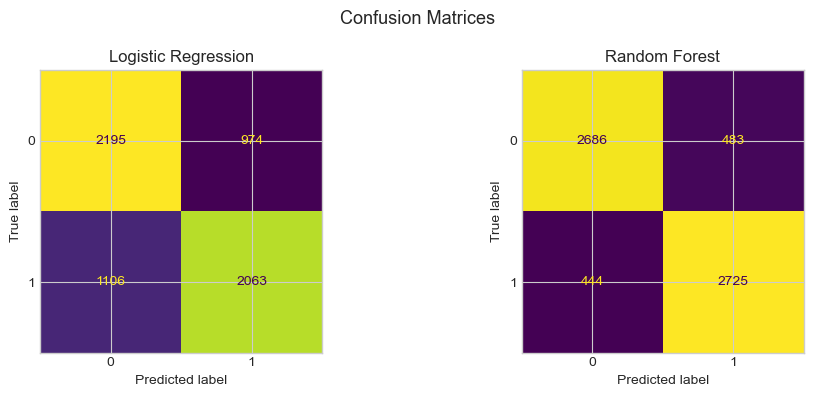

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix=np.array(results["logistic_regression"]["confusion_matrix"]),
    display_labels=[0, 1],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix=np.array(results["random_forest"]["confusion_matrix"]),
    display_labels=[0, 1],
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

fig.suptitle("Confusion Matrices", fontsize=13)
fig.tight_layout()
fig.savefig(figures_dir / "confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()

## Step 8. Random Forest Feature Importance


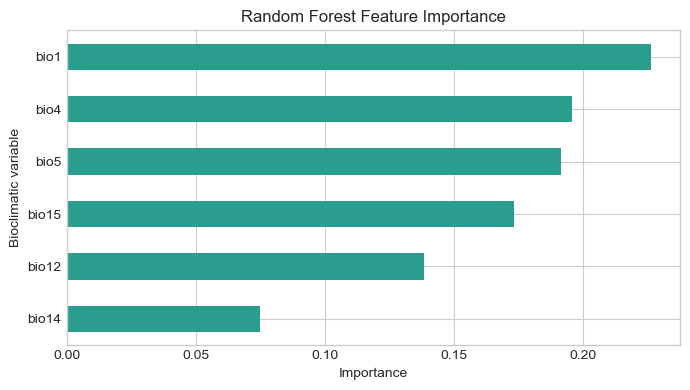

,importance
bio1,0.2261
bio4,0.1958
bio5,0.1913
bio15,0.1733
bio12,0.1385
bio14,0.0749


In [14]:
importance_series = pd.Series(
    results["random_forest"]["feature_importance"],
    name="importance",
).sort_values(ascending=True)

ax = importance_series.plot(kind="barh", figsize=(7, 4), color="#2a9d8f")
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Bioclimatic variable")
plt.tight_layout()
plt.savefig(figures_dir / "rf_feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()

display(importance_series.sort_values(ascending=False).to_frame())

## Step 9. Summary
Species analysed: Ambrosia artemisiifolia
Presence points used after cleaning and raster extraction: 12675
Logistic Regression ROC-AUC: 0.7251
Random Forest ROC-AUC: 0.9240
Best-performing model: Random Forest
Most important BIO variable: bio1
Dominant ecological signal suggested by the model: temperature-related constraints

Interpretation:
The comparison indicates that Random Forest provides the strongest predictive performance on the selected dataset.
This result is expected because ecological relationships are often nonlinear and may include interactions between climatic predictors.
The feature importance ranking shows that bio1 is the most influential variable for distinguishing suitable and unsuitable conditions for Ambrosia artemisiifolia.
Overall, the results suggest that the species distribution in the selected region is influenced primarily by temperature-related factors.

## Answers to the Assessment Questions

**1. What is the main objective of applying classification models in environmental risk detection?**  
The main objective is to assign observations to predefined environmental risk categories such as hazardous versus safe.

**2. Why is overall accuracy often insufficient for evaluating classification models in environmental applications?**  
Accuracy alone may be misleading because environmental datasets are often imbalanced and hazardous events are usually rare.

**3. Which evaluation metric is most critical when the goal is to minimize missed environmental hazards?**  
Recall is the most critical metric because it measures how many actual hazardous cases are correctly detected.

**4. Which algorithm is particularly well-suited for detecting oil spills or marine litter in satellite or drone imagery?**  
Convolutional Neural Networks are the most suitable because they are designed for image-based spatial feature extraction.

**5. What best describes the role of classification model outputs in environmental risk management?**  
They support decision-making by identifying and prioritizing risk categories rather than replacing expert judgement.


## Conclusion

This notebook implements a complete classification workflow for environmental risk detection using openly available biodiversity and climate data. The analysis demonstrates how GBIF occurrence records and WorldClim bioclimatic predictors can be combined to create a reproducible species distribution modeling pipeline. The final comparison between Logistic Regression and Random Forest makes it possible to evaluate both interpretability and predictive strength, while the feature importance plot supports ecological interpretation of climatic constraints.

The workflow illustrates the practical value of classification methods in environmental applications, especially for invasive species monitoring and spatial risk assessment.
